# Flight Delay Prediction
### Steps Completed So Far

## Step 1 — Install & Import Libraries

In [1]:
# Install required libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install imbalanced-learn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

## Step 2 — Load & Inspect the Data

In [2]:
# Load the dataset
features_df = pd.read_csv(r'C:\Users\mukoj\OneDrive\Desktop\Machine Learning Project\Flight cancellation project\Airlines.csv', encoding='ISO-8859-1')

In [3]:
# Shape of the dataset
print(f"Rows: {features_df.shape[0]}, Columns: {features_df.shape[1]}")

Rows: 539383, Columns: 9


In [4]:
# First 5 rows
features_df.head()

,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,1,CO,269,SFO,IAH,3,15,205,1
1,2,US,1558,PHX,CLT,3,15,222,1
2,3,AA,2400,LAX,DFW,3,20,165,1
3,4,AA,2466,SFO,DFW,3,20,195,1
4,5,AS,108,ANC,SEA,3,30,202,0


In [5]:
# Data types of each column
features_df.dtypes

id             int64
Airline          str
Flight         int64
AirportFrom      str
AirportTo        str
DayOfWeek      int64
Time           int64
Length         int64
Delay          int64
dtype: object

In [6]:
# Missing values per column
features_df.isnull().sum()

id             0
Airline        0
Flight         0
AirportFrom    0
AirportTo      0
DayOfWeek      0
Time           0
Length         0
Delay          0
dtype: int64

In [7]:
# Duplicate rows
print(f"Duplicate Rows: {features_df.duplicated().sum()}")

Duplicate Rows: 0


In [8]:
# Basic statistics
features_df.describe()

,id,Flight,DayOfWeek,Time,Length,Delay
count,539383.000000,539383.000000,539383.000000,539383.000000,539383.000000,539383.000000
mean,269692.000000,2427.928630,3.929668,802.728963,132.202007,0.445442
std,155706.604461,2067.429837,1.914664,278.045911,70.117016,0.497015
min,1.000000,1.000000,1.000000,10.000000,0.000000,0.000000
25%,134846.500000,712.000000,2.000000,565.000000,81.000000,0.000000
50%,269692.000000,1809.000000,4.000000,795.000000,115.000000,0.000000
75%,404537.500000,3745.000000,5.000000,1035.000000,162.000000,1.000000
max,539383.000000,7814.000000,7.000000,1439.000000,655.000000,1.000000


## Step 3 — Exploratory Data Analysis (EDA)

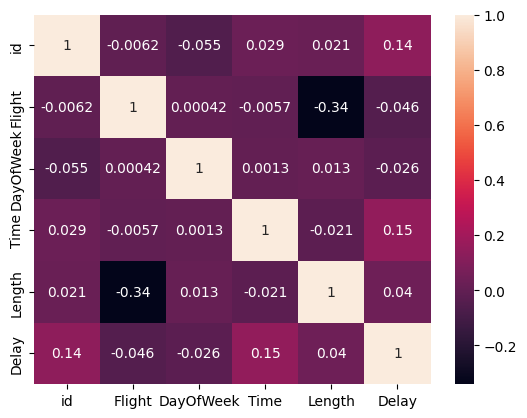

In [9]:
# Correlation heatmap (numeric columns only)
sns.heatmap(features_df.select_dtypes(include='number').corr(), annot=True)
plt.show()

In [10]:
# Correlation matrix
features_df.select_dtypes(include='number').corr()

,id,Flight,DayOfWeek,Time,Length,Delay
id,1.000000,-0.006156,-0.055474,0.029156,0.020781,0.139762
Flight,-0.006156,1.000000,0.000416,-0.005750,-0.341481,-0.046175
DayOfWeek,-0.055474,0.000416,1.000000,0.001273,0.013397,-0.026199
Time,0.029156,-0.005750,0.001273,1.000000,-0.020612,0.150454
Length,0.020781,-0.341481,0.013397,-0.020612,1.000000,0.040489
Delay,0.139762,-0.046175,-0.026199,0.150454,0.040489,1.000000


## Step 4 — Identify Missing Values

In [11]:
# Check missing values
features_df.isnull().sum()
# Result: No missing values found in this dataset

id             0
Airline        0
Flight         0
AirportFrom    0
AirportTo      0
DayOfWeek      0
Time           0
Length         0
Delay          0
dtype: int64

## Step 5 — Detect & Treat Outliers

In [12]:
# Drop id column — not useful for model training
X = features_df.drop(['id'], axis=1)

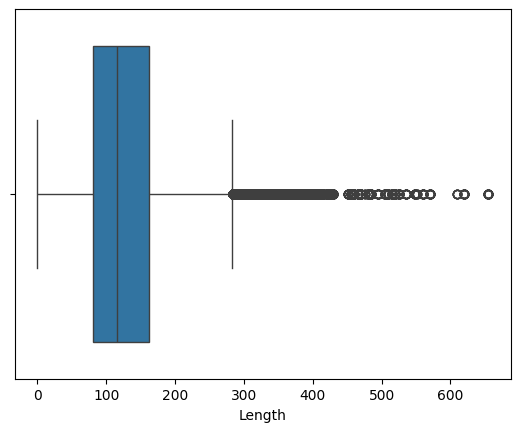

In [13]:
# Visualize outliers using boxplot
sns.boxplot(x=X['Length'])
plt.show()

In [14]:
# Cap outliers in Length column using IQR method
Q1 = X['Length'].quantile(0.25)
Q3 = X['Length'].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

X['Length'] = X['Length'].clip(lower=lower_limit, upper=upper_limit)
print(f"Outliers capped. New max: {X['Length'].max()}, New min: {X['Length'].min()}")

Outliers capped. New max: 283.5, New min: 0.0


## Step 6 — Feature Engineering

In [15]:
# Create IsWeekend column from DayOfWeek
X['IsWeekend'] = X['DayOfWeek'].apply(lambda x: 1 if x >= 6 else 0)

# Create TimeOfDay column from Time
X['TimeOfDay'] = pd.cut(X['Time'], bins=[0, 600, 1200, 1800, 2400],
                        labels=['Night', 'Morning', 'Afternoon', 'Evening'])

print(f"New columns added. Shape: {X.shape}")
X.head()

New columns added. Shape: (539383, 10)


,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay,IsWeekend,TimeOfDay
0,CO,269,SFO,IAH,3,15,205.0,1,0,Night
1,US,1558,PHX,CLT,3,15,222.0,1,0,Night
2,AA,2400,LAX,DFW,3,20,165.0,1,0,Night
3,AA,2466,SFO,DFW,3,20,195.0,1,0,Night
4,AS,108,ANC,SEA,3,30,202.0,0,0,Night


## Step 7 — Encode Categorical Variables

In [16]:
X = pd.get_dummies(X, columns=['Airline', 'AirportFrom', 'AirportTo', 'TimeOfDay'])
print(f"Shape after encoding: {X.shape}")
X.head()

Shape after encoding: (539383, 614)


,Flight,DayOfWeek,Time,Length,Delay,IsWeekend,Airline_9E,Airline_AA,Airline_AS,Airline_B6,...,AirportTo_VLD,AirportTo_VPS,AirportTo_WRG,AirportTo_XNA,AirportTo_YAK,AirportTo_YUM,TimeOfDay_Night,TimeOfDay_Morning,TimeOfDay_Afternoon,TimeOfDay_Evening
0,269,3,15,205.0,1,0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,1558,3,15,222.0,1,0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,2400,3,20,165.0,1,0,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
3,2466,3,20,195.0,1,0,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
4,108,3,30,202.0,0,0,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False


## Step 8 — Feature Scaling

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Columns to scale
cols_to_scale = ['Flight', 'DayOfWeek', 'Time', 'Length']

X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

print("Scaling done")
X.head()

Scaling done


,Flight,DayOfWeek,Time,Length,Delay,IsWeekend,Airline_9E,Airline_AA,Airline_AS,Airline_B6,...,AirportTo_VLD,AirportTo_VPS,AirportTo_WRG,AirportTo_XNA,AirportTo_YAK,AirportTo_YUM,TimeOfDay_Night,TimeOfDay_Morning,TimeOfDay_Afternoon,TimeOfDay_Evening
0,-1.044258,-0.485552,-2.833092,1.209087,1,0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,-0.420778,-0.485552,-2.833092,1.481700,1,0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,-0.013509,-0.485552,-2.815110,0.567644,1,0,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
3,0.018415,-0.485552,-2.815110,1.048726,1,0,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
4,-1.122133,-0.485552,-2.779144,1.160979,0,0,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False


## Step 9 — Train/Test Split


In [18]:
# Separate features and target
y = X['Delay']
X = X.drop(['Delay'], axis=1)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows: {X_test.shape[0]}")

Training rows: 431506
Testing rows: 107877


## Step 10 — Handle Class Imbalance

In [19]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts()}")
print(f"After SMOTE: {y_train_balanced.value_counts()}")

Before SMOTE: Delay
0    239240
1    192266
Name: count, dtype: int64
After SMOTE: Delay
0    239240
1    239240
Name: count, dtype: int64


## Step 11 — Train a Baseline Model

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

# Train baseline model
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_balanced, y_train_balanced)

# Predictions
y_pred = log_model.predict(X_test)

# Evaluation
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall:    {recall_score(y_test, y_pred):.2f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.2f}")

Accuracy:  0.64
Precision: 0.60
Recall:    0.61
F1 Score:  0.60


## Step 12 — Train Multiple Models?

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_balanced, y_train_balanced)
dt_pred = dt_model.predict(X_test)

print("--- Decision Tree ---")
print(f"Accuracy:  {accuracy_score(y_test, dt_pred):.2f}")
print(f"Precision: {precision_score(y_test, dt_pred):.2f}")
print(f"Recall:    {recall_score(y_test, dt_pred):.2f}")
print(f"F1 Score:  {f1_score(y_test, dt_pred):.2f}")

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_balanced, y_train_balanced)
rf_pred = rf_model.predict(X_test)

print("\n--- Random Forest ---")
print(f"Accuracy:  {accuracy_score(y_test, rf_pred):.2f}")
print(f"Precision: {precision_score(y_test, rf_pred):.2f}")
print(f"Recall:    {recall_score(y_test, rf_pred):.2f}")
print(f"F1 Score:  {f1_score(y_test, rf_pred):.2f}")

--- Decision Tree ---
Accuracy:  0.61
Precision: 0.57
Recall:    0.48
F1 Score:  0.52

--- Random Forest ---
Accuracy:  0.62
Precision: 0.57
Recall:    0.57
F1 Score:  0.57


## Hyperparameter Tuning

In [23]:

grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='f1', n_jobs=1)
from sklearn.model_selection import train_test_split

# Use only 20% of balanced data for tuning
X_sample, _, y_sample, _ = train_test_split(X_train_balanced, y_train_balanced, test_size=0.8, random_state=42)

grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='f1', n_jobs=1)
grid_search.fit(X_sample, y_sample)

C:\Users\mukoj\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\mukoj\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'max_iter': [100, 500, ...], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also

In [24]:
# Train final model with best parameters
final_model = LogisticRegression(C=10, solver='liblinear', max_iter=1000, random_state=42)
final_model.fit(X_train_balanced, y_train_balanced)

# Final evaluation
y_final_pred = final_model.predict(X_test)

print("--- Final Model Results ---")
print(f"Accuracy:  {accuracy_score(y_test, y_final_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_final_pred):.2f}")
print(f"Recall:    {recall_score(y_test, y_final_pred):.2f}")
print(f"F1 Score:  {f1_score(y_test, y_final_pred):.2f}")

--- Final Model Results ---
Accuracy:  0.64
Precision: 0.60
Recall:    0.61
F1 Score:  0.60


In [25]:
import joblib

# Save the final model
joblib.dump(final_model, 'flight_delay_model.pkl')
print("Model saved successfully")

# Verify by loading it back
loaded_model = joblib.load('flight_delay_model.pkl')
test_pred = loaded_model.predict(X_test)
print(f"Loaded model F1 Score: {f1_score(y_test, test_pred):.2f}")

Model saved successfully
Loaded model F1 Score: 0.60
